# Chapter 4.4: Multi-Scenario & Transfer Learning

## Learning Objectives

By the end of this notebook, you will be able to:

1. Understand the multi-scenario recommendation problem and its industrial motivation
2. Implement **STAR** (Star Topology Adaptive Recommender, Alibaba 2021)
3. Build **SAMD** (Scenario-Aware Mixture of Domain experts)
4. Design cross-domain recommendation with shared users and different item spaces
5. Evaluate different parameter sharing strategies: full, partial, and adapter-based
6. Understand Tencent's multi-scenario architecture design
7. Build a multi-scenario model with domain-specific adapters

## Prerequisites

- Understanding of multi-task learning
- Familiarity with CTR prediction models
- Knowledge of mixture-of-experts architectures

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part4/chapter_4.4_multi_scenario.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/raw/main/notebooks/part4/chapter_4.4_multi_scenario.ipynb)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Optional, Tuple

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
device = torch.device('cpu')

PyTorch version: 2.2.2


## 1. The Multi-Scenario Problem

Large companies operate multiple recommendation scenarios (apps, pages, use-cases) that share the same users but differ in:
- **Item spaces**: Different products/content types
- **User behavior patterns**: Users behave differently across scenarios
- **Business objectives**: Different KPIs per scenario
- **Data volumes**: Some scenarios are data-rich, others are data-scarce

### Examples
- Alibaba: Homepage, Product Detail, Cart page, After-Purchase
- Tencent: WeChat, QQ, Tencent Video
- Amazon: Product rec, Email rec, Homepage, Sponsored products

> **💡 Concept:** Multi-scenario modeling aims to leverage shared knowledge across scenarios while maintaining scenario-specific personalization. The challenge is balancing the **negative transfer** risk against the **positive transfer** benefit.

In [2]:
def generate_multi_scenario_data(num_users=5000, num_items=2000,
                                  num_scenarios=4, num_features=8,
                                  feature_vocab_sizes=None, seed=42):
    """Generate synthetic multi-scenario CTR data.
    
    Each scenario has different item distribution and CTR patterns,
    but shares the same users and some underlying preference structure.
    """
    np.random.seed(seed)
    if feature_vocab_sizes is None:
        feature_vocab_sizes = [100, 200, 50, 150, 80, 120, 60, 300]
    
    # Shared user preferences
    user_prefs = np.random.randn(num_users, 16).astype(np.float32)
    item_features_latent = np.random.randn(num_items, 16).astype(np.float32)
    
    # Scenario-specific weights
    scenario_weights = np.random.randn(num_scenarios, 16, 16).astype(np.float32) * 0.3
    scenario_bias = np.random.randn(num_scenarios).astype(np.float32) * 0.5
    
    scenarios = {}
    for s in range(num_scenarios):
        n_samples = np.random.randint(2000, 5000)
        users = np.random.randint(0, num_users, size=n_samples)
        items = np.random.randint(0, num_items, size=n_samples)
        
        # Sparse features
        sparse = np.column_stack([
            np.random.randint(0, vs, size=n_samples)
            for vs in feature_vocab_sizes
        ])
        
        # Labels with scenario-specific patterns
        user_vecs = user_prefs[users]
        item_vecs = item_features_latent[items]
        transformed = user_vecs @ scenario_weights[s]
        logits = (transformed * item_vecs).sum(axis=1) + scenario_bias[s]
        logits += 0.1 * sparse[:, 0] / feature_vocab_sizes[0]  # Feature interaction
        probs = 1 / (1 + np.exp(-logits))
        labels = (np.random.rand(n_samples) < probs).astype(np.float32)
        
        scenarios[s] = {
            'users': torch.LongTensor(users),
            'items': torch.LongTensor(items),
            'sparse': torch.LongTensor(sparse),
            'labels': torch.FloatTensor(labels),
            'scenario_id': s
        }
    
    return scenarios, feature_vocab_sizes


NUM_SCENARIOS = 4
NUM_ITEMS = 2000
NUM_USERS = 5000
EMBED_DIM = 32
NUM_FEATURES = 8

scenario_data, feature_vocab_sizes = generate_multi_scenario_data()

for s, data in scenario_data.items():
    print(f"Scenario {s}: {len(data['labels'])} samples, CTR: {data['labels'].mean():.3f}")

Scenario 0: 4470 samples, CTR: 0.522
Scenario 1: 3886 samples, CTR: 0.524
Scenario 2: 2813 samples, CTR: 0.581
Scenario 3: 2150 samples, CTR: 0.460


## 2. STAR: Star Topology Adaptive Recommender (Alibaba, 2021)

STAR uses a **star topology** where a shared centered network connects to multiple domain-specific networks. The key innovation is **element-wise** combination of shared and domain-specific parameters.

### Architecture

For each layer, STAR combines shared weights $W^*$ with domain-specific weights $W^d$:

$$W^{\text{final}}_d = W^* \odot W^d$$
$$\mathbf{b}^{\text{final}}_d = \mathbf{b}^* + \mathbf{b}^d$$

The element-wise product allows the shared network to modulate domain-specific behavior while maintaining domain specialization.

> **🔑 Pro Tip:** STAR's star topology is more parameter-efficient than maintaining fully separate models per scenario while being more expressive than simple hard parameter sharing.

In [3]:
class StarLinear(nn.Module):
    """STAR-style linear layer with shared * domain-specific weights."""
    def __init__(self, in_features: int, out_features: int, num_domains: int):
        super().__init__()
        self.num_domains = num_domains
        
        # Shared (centered) parameters
        self.shared_weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.shared_bias = nn.Parameter(torch.zeros(out_features))
        
        # Domain-specific parameters
        self.domain_weights = nn.ParameterList([
            nn.Parameter(torch.ones(out_features, in_features))
            for _ in range(num_domains)
        ])
        self.domain_biases = nn.ParameterList([
            nn.Parameter(torch.zeros(out_features))
            for _ in range(num_domains)
        ])
    
    def forward(self, x: torch.Tensor, domain_id: int) -> torch.Tensor:
        # Element-wise combination
        weight = self.shared_weight * self.domain_weights[domain_id]
        bias = self.shared_bias + self.domain_biases[domain_id]
        return F.linear(x, weight, bias)


class STAR(nn.Module):
    """Star Topology Adaptive Recommender."""
    def __init__(self, vocab_sizes: List[int], embed_dim: int,
                 num_domains: int, hidden_dims: List[int] = None):
        super().__init__()
        self.num_domains = num_domains
        
        self.embeddings = nn.ModuleList([
            nn.Embedding(vs, embed_dim) for vs in vocab_sizes
        ])
        
        input_dim = embed_dim * len(vocab_sizes)
        if hidden_dims is None:
            hidden_dims = [256, 128, 64]
        
        # Star layers
        self.star_layers = nn.ModuleList()
        prev = input_dim
        for dim in hidden_dims:
            self.star_layers.append(StarLinear(prev, dim, num_domains))
            prev = dim
        
        self.output_layer = StarLinear(prev, 1, num_domains)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(0.1)
    
    def forward(self, sparse_features: torch.Tensor, domain_id: int) -> torch.Tensor:
        embeds = [self.embeddings[i](sparse_features[:, i]) for i in range(sparse_features.size(1))]
        x = torch.cat(embeds, dim=-1)
        
        for layer in self.star_layers:
            x = layer(x, domain_id)
            x = self.activation(x)
            x = self.dropout(x)
        
        return self.output_layer(x, domain_id).squeeze(-1)


model_star = STAR(feature_vocab_sizes, EMBED_DIM, NUM_SCENARIOS)
test_logits = model_star(scenario_data[0]['sparse'][:16], domain_id=0)
print(f"STAR output shape: {test_logits.shape}")
print(f"STAR parameters: {sum(p.numel() for p in model_star.parameters()):,}")

STAR output shape: torch.Size([16])
STAR parameters: 568,965


## 3. SAMD: Scenario-Aware Mixture of Domain Experts

SAMD uses a **mixture of experts** approach where different experts specialize in different scenarios, and a scenario-aware gating network routes inputs to appropriate experts.

### Architecture

$$\mathbf{h} = \sum_{k=1}^K g_k(\mathbf{x}, s) \cdot E_k(\mathbf{x})$$

where $g_k(\mathbf{x}, s)$ is the scenario-aware gating function and $E_k$ are expert networks.

> **💡 Concept:** Unlike standard MoE where gating depends only on input features, SAMD's gating explicitly conditions on the scenario ID, allowing the model to learn scenario-specific expert combinations.

In [4]:
class ExpertNetwork(nn.Module):
    """Single expert MLP."""
    def __init__(self, input_dim: int, output_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, output_dim),
            nn.ReLU(),
            nn.Linear(output_dim, output_dim)
        )
    
    def forward(self, x):
        return self.net(x)


class SAMD(nn.Module):
    """Scenario-Aware Mixture of Domain experts."""
    def __init__(self, vocab_sizes: List[int], embed_dim: int,
                 num_scenarios: int, num_experts: int = 6,
                 hidden_dim: int = 128):
        super().__init__()
        self.num_experts = num_experts
        self.num_scenarios = num_scenarios
        
        self.embeddings = nn.ModuleList([
            nn.Embedding(vs, embed_dim) for vs in vocab_sizes
        ])
        self.scenario_embedding = nn.Embedding(num_scenarios, embed_dim)
        
        input_dim = embed_dim * len(vocab_sizes)
        
        # Shared experts
        self.shared_experts = nn.ModuleList([
            ExpertNetwork(input_dim, hidden_dim)
            for _ in range(num_experts // 2)
        ])
        
        # Domain-specific experts
        self.domain_experts = nn.ModuleList([
            ExpertNetwork(input_dim, hidden_dim)
            for _ in range(num_experts // 2)
        ])
        
        # Scenario-aware gating
        self.gate = nn.Sequential(
            nn.Linear(input_dim + embed_dim, 64),  # input + scenario embedding
            nn.ReLU(),
            nn.Linear(64, num_experts)
        )
        
        # Output tower
        self.output = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )
    
    def forward(self, sparse_features: torch.Tensor, scenario_id: int) -> torch.Tensor:
        embeds = [self.embeddings[i](sparse_features[:, i]) for i in range(sparse_features.size(1))]
        x = torch.cat(embeds, dim=-1)
        
        # Scenario embedding
        batch_size = x.size(0)
        scenario_ids = torch.full((batch_size,), scenario_id, dtype=torch.long)
        scenario_embed = self.scenario_embedding(scenario_ids)
        
        # All expert outputs
        all_experts = list(self.shared_experts) + list(self.domain_experts)
        expert_outputs = torch.stack([e(x) for e in all_experts], dim=1)  # (batch, num_experts, hidden)
        
        # Scenario-aware gating
        gate_input = torch.cat([x, scenario_embed], dim=-1)
        gate_weights = F.softmax(self.gate(gate_input), dim=-1)  # (batch, num_experts)
        
        # Weighted combination
        combined = torch.einsum('be,bed->bd', gate_weights, expert_outputs)
        
        return self.output(combined).squeeze(-1)


model_samd = SAMD(feature_vocab_sizes, EMBED_DIM, NUM_SCENARIOS)
test_logits = model_samd(scenario_data[0]['sparse'][:16], scenario_id=0)
print(f"SAMD output shape: {test_logits.shape}")
print(f"SAMD parameters: {sum(p.numel() for p in model_samd.parameters()):,}")

SAMD output shape: torch.Size([16])
SAMD parameters: 357,703


## 4. Parameter Sharing Strategies

Let's compare different parameter sharing strategies for multi-scenario recommendation.

### Strategies

1. **Full Sharing**: One model for all scenarios (just concatenate scenario ID)
2. **No Sharing**: Separate model per scenario
3. **Partial Sharing (STAR)**: Shared backbone with scenario-specific modulation
4. **Adapter-Based**: Shared backbone with lightweight scenario adapters

> **⚠️ Common Pitfall:** Full sharing can cause the seesaw effect where improving one scenario hurts another. This is especially common when scenarios have very different data distributions.

In [5]:
class FullSharingModel(nn.Module):
    """Single model for all scenarios with scenario ID as a feature."""
    def __init__(self, vocab_sizes, embed_dim, num_scenarios):
        super().__init__()
        self.embeddings = nn.ModuleList([nn.Embedding(vs, embed_dim) for vs in vocab_sizes])
        self.scenario_embedding = nn.Embedding(num_scenarios, embed_dim)
        input_dim = embed_dim * (len(vocab_sizes) + 1)
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 1)
        )
    
    def forward(self, sparse_features, scenario_id):
        embeds = [self.embeddings[i](sparse_features[:, i]) for i in range(sparse_features.size(1))]
        batch_size = sparse_features.size(0)
        scenario_embed = self.scenario_embedding(torch.full((batch_size,), scenario_id, dtype=torch.long))
        embeds.append(scenario_embed)
        x = torch.cat(embeds, dim=-1)
        return self.mlp(x).squeeze(-1)


class SeparateModels(nn.Module):
    """Separate model per scenario (no sharing)."""
    def __init__(self, vocab_sizes, embed_dim, num_scenarios):
        super().__init__()
        self.models = nn.ModuleList()
        for _ in range(num_scenarios):
            embeddings = nn.ModuleList([nn.Embedding(vs, embed_dim) for vs in vocab_sizes])
            input_dim = embed_dim * len(vocab_sizes)
            mlp = nn.Sequential(
                nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.1),
                nn.Linear(128, 64), nn.ReLU(),
                nn.Linear(64, 1)
            )
            self.models.append(nn.ModuleDict({'embeddings': embeddings, 'mlp': mlp}))
    
    def forward(self, sparse_features, scenario_id):
        model = self.models[scenario_id]
        embeds = [model['embeddings'][i](sparse_features[:, i]) for i in range(sparse_features.size(1))]
        x = torch.cat(embeds, dim=-1)
        return model['mlp'](x).squeeze(-1)


class AdapterModel(nn.Module):
    """Shared backbone with scenario-specific adapters."""
    def __init__(self, vocab_sizes, embed_dim, num_scenarios, adapter_dim=16):
        super().__init__()
        self.embeddings = nn.ModuleList([nn.Embedding(vs, embed_dim) for vs in vocab_sizes])
        input_dim = embed_dim * len(vocab_sizes)
        
        # Shared backbone
        self.shared = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, 128), nn.ReLU()
        )
        
        # Scenario-specific adapters
        self.adapters = nn.ModuleList([
            nn.Sequential(
                nn.Linear(128, adapter_dim),
                nn.ReLU(),
                nn.Linear(adapter_dim, 128)
            ) for _ in range(num_scenarios)
        ])
        
        self.output = nn.Linear(128, 1)
    
    def forward(self, sparse_features, scenario_id):
        embeds = [self.embeddings[i](sparse_features[:, i]) for i in range(sparse_features.size(1))]
        x = torch.cat(embeds, dim=-1)
        h = self.shared(x)
        h = h + self.adapters[scenario_id](h)  # Residual adapter
        return self.output(h).squeeze(-1)

In [6]:
def train_multi_scenario(model, scenario_data, epochs=15, lr=1e-3, batch_size=128):
    """Train a multi-scenario model."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    
    history = {s: {'loss': []} for s in scenario_data}
    
    for epoch in range(epochs):
        model.train()
        for s, data in scenario_data.items():
            n = len(data['labels'])
            perm = torch.randperm(n)
            epoch_loss = 0
            count = 0
            for i in range(0, min(n, 1024), batch_size):
                idx = perm[i:i+batch_size]
                optimizer.zero_grad()
                logits = model(data['sparse'][idx], s)
                loss = criterion(logits, data['labels'][idx])
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
                count += 1
            history[s]['loss'].append(epoch_loss / max(count, 1))
    
    return history


# Train all models
strategies = {
    'Full Sharing': FullSharingModel(feature_vocab_sizes, EMBED_DIM, NUM_SCENARIOS),
    'STAR': STAR(feature_vocab_sizes, EMBED_DIM, NUM_SCENARIOS),
    'SAMD': SAMD(feature_vocab_sizes, EMBED_DIM, NUM_SCENARIOS),
    'Adapter': AdapterModel(feature_vocab_sizes, EMBED_DIM, NUM_SCENARIOS),
}

all_results = {}
for name, model in strategies.items():
    torch.manual_seed(42)
    results = train_multi_scenario(model, scenario_data)
    all_results[name] = results
    avg_final = np.mean([results[s]['loss'][-1] for s in results])
    params = sum(p.numel() for p in model.parameters())
    print(f"{name:15s} | Avg Loss: {avg_final:.4f} | Params: {params:>10,}")

Full Sharing    | Avg Loss: 0.5208 | Params:    141,057


STAR            | Avg Loss: 0.4218 | Params:    568,965


SAMD            | Avg Loss: 0.2771 | Params:    357,703


Adapter         | Avg Loss: 0.3930 | Params:    149,697


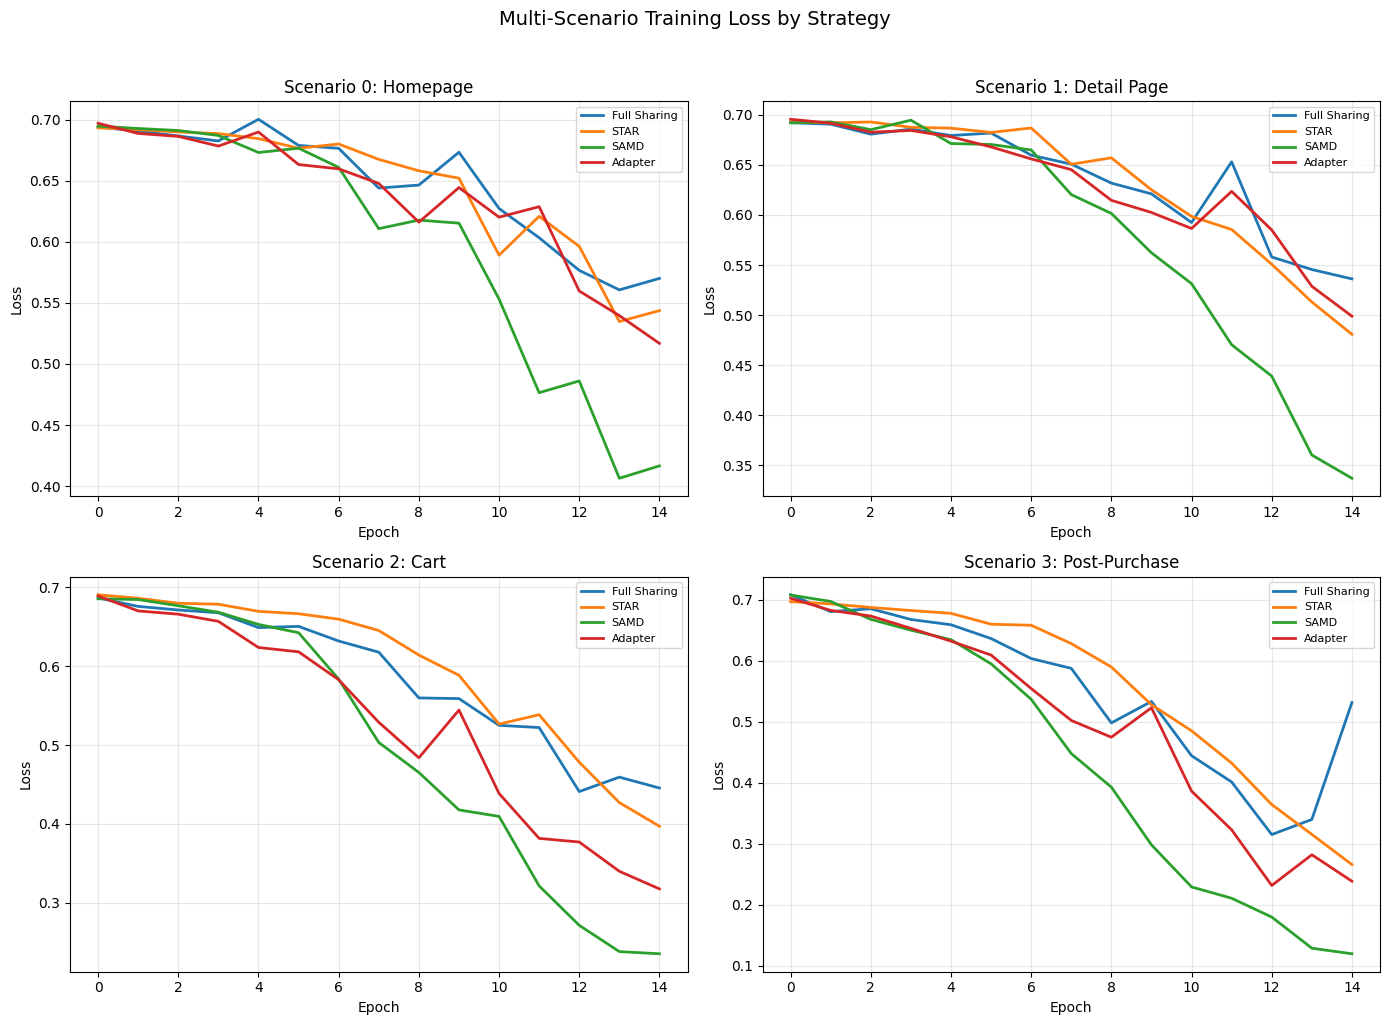

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
scenario_names = ['Homepage', 'Detail Page', 'Cart', 'Post-Purchase']

for s_idx, (ax, s_name) in enumerate(zip(axes.flat, scenario_names)):
    for strategy_name, results in all_results.items():
        ax.plot(results[s_idx]['loss'], label=strategy_name, linewidth=2)
    ax.set_title(f'Scenario {s_idx}: {s_name}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Multi-Scenario Training Loss by Strategy', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Cross-Domain Recommendation

Cross-domain recommendation handles scenarios where the **item spaces** are completely different (e.g., movies vs books) but users overlap.

### Approaches

1. **Shared user embeddings**: Learn user embeddings shared across domains
2. **Cross-domain mapping**: Learn a mapping function between domain representations
3. **Dual-tower with shared encoder**: Share the user encoder, separate item encoders

> **💡 Concept:** Cross-domain recommendation differs from multi-scenario in that the item spaces are disjoint. The transfer happens through shared user representations, not shared item features.

In [8]:
class CrossDomainModel(nn.Module):
    """Cross-domain recommendation with shared user encoder."""
    def __init__(self, num_users: int, domain_item_counts: List[int],
                 user_dim: int = 64, item_dim: int = 32):
        super().__init__()
        self.num_domains = len(domain_item_counts)
        
        # Shared user encoder
        self.user_embedding = nn.Embedding(num_users, user_dim)
        self.user_encoder = nn.Sequential(
            nn.Linear(user_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )
        
        # Domain-specific item encoders
        self.item_embeddings = nn.ModuleList([
            nn.Embedding(count, item_dim)
            for count in domain_item_counts
        ])
        self.item_encoders = nn.ModuleList([
            nn.Sequential(
                nn.Linear(item_dim, 64),
                nn.ReLU(),
                nn.Linear(64, 64)
            ) for _ in domain_item_counts
        ])
        
        # Domain-specific prediction heads
        self.predictors = nn.ModuleList([
            nn.Linear(128, 1) for _ in domain_item_counts
        ])
    
    def forward(self, user_ids, item_ids, domain_id):
        user_repr = self.user_encoder(self.user_embedding(user_ids))
        item_repr = self.item_encoders[domain_id](self.item_embeddings[domain_id](item_ids))
        combined = torch.cat([user_repr, item_repr], dim=-1)
        return self.predictors[domain_id](combined).squeeze(-1)


# Test cross-domain model
cross_model = CrossDomainModel(NUM_USERS, [1000, 800, 500])
test_users = torch.randint(0, NUM_USERS, (16,))
test_items = torch.randint(0, 1000, (16,))
logits = cross_model(test_users, test_items, domain_id=0)
print(f"Cross-domain output shape: {logits.shape}")
print(f"Cross-domain parameters: {sum(p.numel() for p in cross_model.parameters()):,}")

Cross-domain output shape: torch.Size([16])
Cross-domain parameters: 429,379


## 6. Tencent-Style Multi-Scenario Architecture

Tencent's approach combines multiple techniques:
1. **Shared bottom layers** for feature extraction
2. **Scenario-specific expert routing** using MMoE (Multi-gate Mixture of Experts)
3. **Progressive layered extraction** (PLE) to reduce negative transfer

This architecture serves WeChat, QQ, and Tencent Video from a unified model.

In [9]:
class PLELayer(nn.Module):
    """Progressive Layered Extraction layer (Tencent, 2020)."""
    def __init__(self, input_dim: int, output_dim: int,
                 num_shared_experts: int = 2, num_task_experts: int = 2,
                 num_tasks: int = 4):
        super().__init__()
        self.num_tasks = num_tasks
        total_experts = num_shared_experts + num_task_experts * num_tasks
        
        # Shared experts
        self.shared_experts = nn.ModuleList([
            nn.Sequential(nn.Linear(input_dim, output_dim), nn.ReLU())
            for _ in range(num_shared_experts)
        ])
        
        # Task-specific experts
        self.task_experts = nn.ModuleList([
            nn.ModuleList([
                nn.Sequential(nn.Linear(input_dim, output_dim), nn.ReLU())
                for _ in range(num_task_experts)
            ]) for _ in range(num_tasks)
        ])
        
        # Task-specific gates
        self.gates = nn.ModuleList([
            nn.Linear(input_dim, num_shared_experts + num_task_experts)
            for _ in range(num_tasks)
        ])
    
    def forward(self, x: torch.Tensor) -> List[torch.Tensor]:
        shared_outputs = [e(x) for e in self.shared_experts]
        
        task_outputs = []
        for t in range(self.num_tasks):
            # Combine shared + task-specific experts
            task_expert_outputs = [e(x) for e in self.task_experts[t]]
            all_outputs = shared_outputs + task_expert_outputs
            expert_stack = torch.stack(all_outputs, dim=1)  # (batch, num_experts, dim)
            
            # Gating
            gate_weights = F.softmax(self.gates[t](x), dim=-1)  # (batch, num_experts)
            output = torch.einsum('be,bed->bd', gate_weights, expert_stack)
            task_outputs.append(output)
        
        return task_outputs


class TencentMultiScenario(nn.Module):
    """Tencent-style multi-scenario model with PLE."""
    def __init__(self, vocab_sizes: List[int], embed_dim: int,
                 num_scenarios: int, num_ple_layers: int = 2):
        super().__init__()
        self.embeddings = nn.ModuleList([nn.Embedding(vs, embed_dim) for vs in vocab_sizes])
        
        input_dim = embed_dim * len(vocab_sizes)
        hidden_dim = 128
        
        # PLE layers
        self.ple_layers = nn.ModuleList()
        prev_dim = input_dim
        for _ in range(num_ple_layers):
            self.ple_layers.append(PLELayer(prev_dim, hidden_dim, num_tasks=num_scenarios))
            prev_dim = hidden_dim
        
        # Scenario-specific towers
        self.towers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, 64), nn.ReLU(),
                nn.Linear(64, 1)
            ) for _ in range(num_scenarios)
        ])
    
    def forward(self, sparse_features: torch.Tensor, scenario_id: int) -> torch.Tensor:
        embeds = [self.embeddings[i](sparse_features[:, i]) for i in range(sparse_features.size(1))]
        x = torch.cat(embeds, dim=-1)
        
        for ple in self.ple_layers:
            outputs = ple(x)
            x = outputs[scenario_id]  # Use task-specific output for next layer
        
        return self.towers[scenario_id](x).squeeze(-1)


model_tencent = TencentMultiScenario(feature_vocab_sizes, EMBED_DIM, NUM_SCENARIOS)
logits = model_tencent(scenario_data[0]['sparse'][:16], scenario_id=0)
print(f"Tencent model output: {logits.shape}")
print(f"Tencent model params: {sum(p.numel() for p in model_tencent.parameters()):,}")

Tencent model output: torch.Size([16])
Tencent model params: 567,460


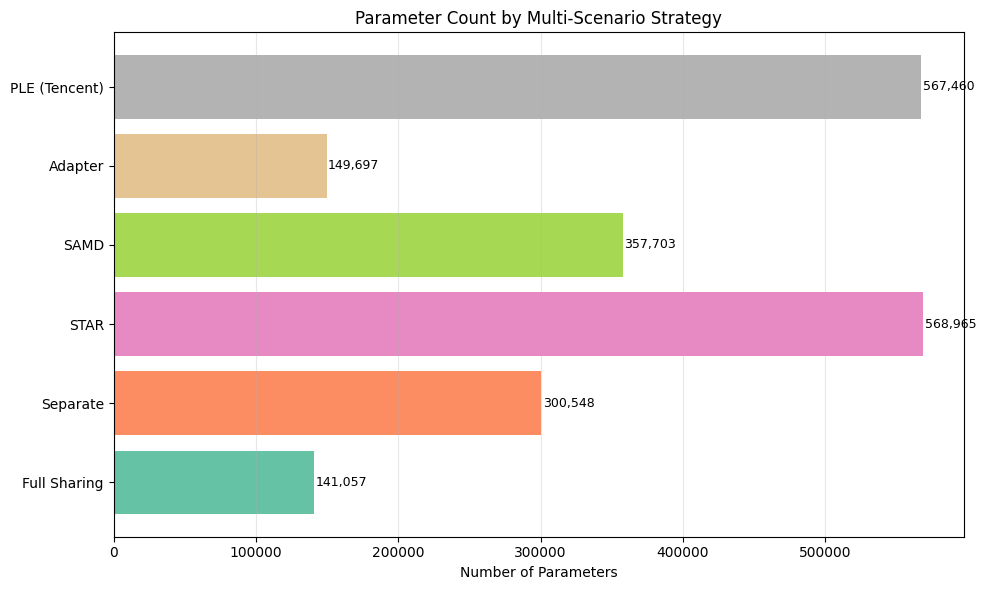

In [10]:
# Compare parameter efficiency
model_params = {
    'Full Sharing': sum(p.numel() for p in strategies['Full Sharing'].parameters()),
    'Separate': sum(p.numel() for p in SeparateModels(feature_vocab_sizes, EMBED_DIM, NUM_SCENARIOS).parameters()),
    'STAR': sum(p.numel() for p in strategies['STAR'].parameters()),
    'SAMD': sum(p.numel() for p in strategies['SAMD'].parameters()),
    'Adapter': sum(p.numel() for p in strategies['Adapter'].parameters()),
    'PLE (Tencent)': sum(p.numel() for p in model_tencent.parameters()),
}

fig, ax = plt.subplots(figsize=(10, 6))
names = list(model_params.keys())
params = [model_params[n] for n in names]
colors = plt.cm.Set2(np.linspace(0, 1, len(names)))

bars = ax.barh(names, params, color=colors)
ax.set_xlabel('Number of Parameters')
ax.set_title('Parameter Count by Multi-Scenario Strategy')
for bar, p in zip(bars, params):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'{p:,}', va='center', fontsize=9)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Exercises

### 🏋️ Exercise 1: Build a Multi-Scenario Model with Domain-Specific Adapters

Implement an enhanced adapter model with scenario-aware batch normalization.

In [11]:
class ScenarioAwareBatchNorm(nn.Module):
    """Batch normalization with scenario-specific affine parameters.
    
    Shared running statistics but scenario-specific gamma and beta.
    """
    def __init__(self, num_features: int, num_scenarios: int):
        super().__init__()
        # TODO: Implement scenario-aware batch norm
        # 1. Shared batch norm (without affine)
        # 2. Scenario-specific gamma and beta
        pass
    
    def forward(self, x: torch.Tensor, scenario_id: int) -> torch.Tensor:
        # TODO: Apply shared normalization then scenario-specific affine
        pass


class EnhancedAdapterModel(nn.Module):
    """Shared backbone + adapters + scenario-aware BN.
    
    Architecture:
    - Shared embedding layer
    - Shared MLP layers with scenario-aware batch norm
    - Bottleneck adapters after each shared layer
    - Scenario-specific output head
    """
    def __init__(self, vocab_sizes, embed_dim, num_scenarios):
        super().__init__()
        # TODO: Implement enhanced adapter model
        pass
    
    def forward(self, sparse_features, scenario_id):
        # TODO: Implement forward pass
        pass


# TODO: Train and compare with other strategies

### 🏋️ Exercise 2: Measure Negative Transfer

Implement a function to quantify negative transfer between scenarios.

In [12]:
def measure_negative_transfer(multi_scenario_model, separate_models,
                                scenario_data, num_scenarios):
    """Measure negative transfer by comparing multi-scenario vs separate models.
    
    Negative transfer ratio for scenario s:
        NTR_s = (loss_multi_s - loss_separate_s) / loss_separate_s
    
    NTR > 0 indicates negative transfer (multi-scenario hurts this scenario).
    NTR < 0 indicates positive transfer (multi-scenario helps).
    
    TODO:
    1. Evaluate both models on each scenario
    2. Compute NTR per scenario
    3. Visualize with a bar chart
    """
    pass


# TODO: Train separate models and measure negative transfer

### 🏋️ Exercise 3: Scenario-Aware Expert Routing Visualization

Visualize how the SAMD gating network routes different scenarios to different experts.

In [13]:
def visualize_expert_routing(model, scenario_data, num_scenarios):
    """Visualize expert utilization per scenario.
    
    TODO:
    1. Pass data from each scenario through the model
    2. Record the average gating weights per scenario
    3. Create a heatmap showing scenario -> expert routing patterns
    4. Annotate which experts are shared vs domain-specific
    """
    pass


# TODO: visualize_expert_routing(model_samd, scenario_data, NUM_SCENARIOS)

## Summary

In this notebook, we explored multi-scenario and transfer learning for ranking:

| Method | Sharing Strategy | Key Innovation | Paper |
|--------|-----------------|----------------|-------|
| **STAR** | Element-wise shared*domain | Star topology | Alibaba, 2021 |
| **SAMD** | Scenario-aware MoE | Scenario-conditioned gating | — |
| **PLE** | Progressive layered extraction | Shared+task experts per layer | Tencent, 2020 |
| **Adapter** | Shared backbone + adapters | Bottleneck residual adapters | — |

**Key takeaways:**
- Multi-scenario models can leverage shared knowledge but risk negative transfer
- Star topology (element-wise product) is a simple yet effective sharing strategy
- Scenario-aware gating helps route inputs to appropriate experts
- Adapter-based approaches offer the best parameter efficiency
- PLE's progressive extraction reduces inter-task interference